In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, t

In [2]:
data = pd.read_csv('QVI_data.csv')
print(data.head())
print(data.info())


   LYLTY_CARD_NBR        DATE  STORE_NBR  TXN_ID  PROD_NBR  \
0            1000  2018-10-17          1       1         5   
1            1002  2018-09-16          1       2        58   
2            1003  2019-03-07          1       3        52   
3            1003  2019-03-08          1       4       106   
4            1004  2018-11-02          1       5        96   

                                PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0  Natural Chip        Compny SeaSalt175g         2        6.0        175   
1   Red Rock Deli Chikn&Garlic Aioli 150g         1        2.7        150   
2   Grain Waves Sour    Cream&Chives 210G         1        3.6        210   
3  Natural ChipCo      Hony Soy Chckn175g         1        3.0        175   
4          WW Original Stacked Chips 160g         1        1.9        160   

        BRAND              LIFESTAGE PREMIUM_CUSTOMER  
0     NATURAL  YOUNG SINGLES/COUPLES          Premium  
1         RRD  YOUNG SINGLES/COUPLES       Mainstrea

In [3]:
#some basic cleaning
data['DATE'] = pd.to_datetime(data['DATE'])
data = data[~data['PROD_NAME'].str.lower().str.contains('salsa')]
data = data[data['PROD_QTY'] < 200]

data['YEARMONTH'] = data['DATE'].dt.strftime("%Y%m").astype(int) #creating a yearmonth

#aggregation
monthly_stats = data.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    totalSales=('TOT_SALES', 'sum'), 
    nCustomers=('LYLTY_CARD_NBR', 'nunique'), 
    nTransactions=('TXN_ID', 'nunique')).reset_index()

monthly_stats['nTxnPerCust'] = monthly_stats['nTransactions'] / monthly_stats['nCustomers']

store_counts = monthly_stats.groupby('STORE_NBR')['YEARMONTH'].count()
full_year_stores = store_counts[store_counts == 12].index
monthly_stats = monthly_stats[monthly_stats['STORE_NBR'].isin(full_year_stores)]

print(f"Number of stores in the final pool: {len(full_year_stores)}")

Number of stores in the final pool: 259


In [4]:
preTrialPeriod = monthly_stats[monthly_stats['YEARMONTH'] < 201902]

#lets calculate the pearson correlation between a trial store and all other stores.
def calculateCorrelation(inputTable, metricCol, storeComparison):
    control_stores = inputTable['STORE_NBR'].unique()
    corrs = []
    
    trial_data = inputTable[inputTable['STORE_NBR'] == storeComparison][metricCol].values
    
    for store in control_stores:
        control_data = inputTable[inputTable['STORE_NBR'] == store][metricCol].values

        corr = np.corrcoef(trial_data, control_data)[0, 1]
        corrs.append((store, corr))
    
    return pd.DataFrame(corrs, columns=['STORE_NBR', 'Correlation'])

#it calculates the magnitude distance: 1 - normalized abs difference
def calculateMagnitude(inputTable, metricCol, storeComparison):
    control_stores = inputTable['STORE_NBR'].unique()
    magnitudes = []
    trial_data = inputTable[inputTable['STORE_NBR'] == storeComparison][metricCol].values
    
    for store in control_stores:
        control_data = inputTable[inputTable['STORE_NBR'] == store][metricCol].values

        dist = np.mean(np.abs(trial_data - control_data))
        magnitudes.append((store, dist))
    
    df_mag = pd.DataFrame(magnitudes, columns=['STORE_NBR', 'Dist'])

    df_mag['Magnitude'] = 1 - (df_mag['Dist'] - df_mag['Dist'].min()) / (df_mag['Dist'].max() - df_mag['Dist'].min())
    return df_mag[['STORE_NBR', 'Magnitude']]
    

In [5]:
#trying to find the twin for store 77 again
#hopefully the colum names dont break this time 
corr_sales = calculateCorrelation(preTrialPeriod, 'totalSales', 77)
mag_sales = calculateMagnitude(preTrialPeriod, 'totalSales', 77)
corr_cust = calculateCorrelation(preTrialPeriod, 'nCustomers', 77)
mag_cust = calculateMagnitude(preTrialPeriod, 'nCustomers', 77)

scores = corr_sales.merge(mag_sales, on='STORE_NBR')
scores.columns = ['STORE_NBR', 'corr_sales', 'mag_sales']

scores = scores.merge(corr_cust, on='STORE_NBR')
scores = scores.merge(mag_cust, on='STORE_NBR')

scores.columns = ['STORE_NBR', 'corr_sales', 'mag_sales', 'corr_cust', 'mag_cust']

scores['finalscore'] = (scores['corr_sales'] + scores['mag_sales'] + 
                        scores['corr_cust'] + scores['mag_cust']) / 4

best_match = scores[scores['STORE_NBR'] != 77].sort_values(by='finalscore', ascending=False).head(1)
print(f"the best twin for store 77 is: {best_match['STORE_NBR'].values[0]}")

the best twin for store 77 is: 233


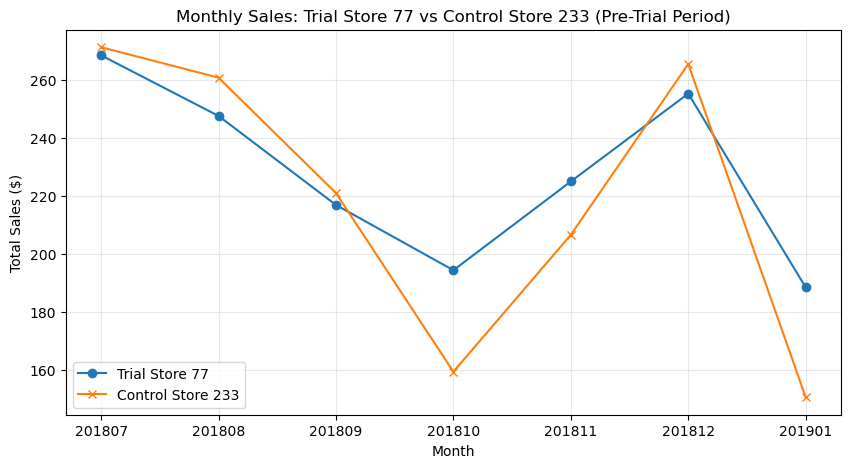

In [6]:
#visual check to see if our twin (233) actually behaves like Store 77
trial_store = 77
control_store = 233

#grabing the pre-trial data for both
#Note: I'm converting YEARMONTH to string so the x-axis doesn't look like weird numbers
trial_sales = preTrialPeriod[preTrialPeriod['STORE_NBR'] == trial_store]
control_sales = preTrialPeriod[preTrialPeriod['STORE_NBR'] == control_store]

plt.figure(figsize=(10, 5))
plt.plot(trial_sales['YEARMONTH'].astype(str), trial_sales['totalSales'], label='Trial Store 77', marker='o')
plt.plot(control_sales['YEARMONTH'].astype(str), control_sales['totalSales'], label='Control Store 233', marker='x')
plt.title('Monthly Sales: Trial Store 77 vs Control Store 233 (Pre-Trial Period)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [7]:
#scaling the Control Store to match the Trial Store's scale

#calculating the scaling factor for Sales
trial_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == 77]['totalSales'].sum()

control_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == 233]['totalSales'].sum()
scaling_factor_sales = trial_sum / control_sum

#appling it to the Control Store's data in the main monthly_stats table
scaled_control_sales = monthly_stats[monthly_stats['STORE_NBR'] == 233].copy()
scaled_control_sales['controlSales'] = scaled_control_sales['totalSales'] * scaling_factor_sales

#calculating the percentage difference between trial and scaled control
trial_sales = monthly_stats[monthly_stats['STORE_NBR'] == 77][['YEARMONTH', 'totalSales']]

compare_sales = pd.merge(trial_sales, scaled_control_sales[['YEARMONTH', 'controlSales']], on='YEARMONTH')
compare_sales['percentageDiff'] = abs(compare_sales['totalSales'] - compare_sales['controlSales']) / compare_sales['controlSales']


print("Scaling factor for Sales:", round(scaling_factor_sales, 4))
print(compare_sales.head(12)) # Look at the diffs for the trial months (201902-201904)

Scaling factor for Sales: 1.0398
    YEARMONTH  totalSales  controlSales  percentageDiff
0      201807       268.4    281.980841        0.048162
1      201808       247.5    271.063441        0.086930
2      201809       216.8    229.681297        0.056083
3      201810       194.3    165.632551        0.173079
4      201811       224.9    214.708863        0.047465
5      201812       255.2    275.950277        0.075196
6      201901       188.4    156.482731        0.203967
7      201902       211.6    229.473346        0.077889
8      201903       255.1    187.779277        0.358510
9      201904       258.1    149.932291        0.721444
10     201905       272.3    324.506712        0.160880
11     201906       246.6    204.831215        0.203918


Store 233 is not the exact same “size” as 77 in terms of sales level, so comparing them directly wouldn’t be fully fair. To fix that, I calculated a scaling factor using their total sales in the pre-trial period. The factor is 1.0398, so basically I adjusted the control store slightly upward to match store 77’s normal level.
After scaling, I treated those numbers as the “expected” sales for store 77 if nothing changed. Then I computed the percentage difference each month to see how far the actual sales move away from that baseline.
Before the trial, the differences are there but still kind of reasonable and not crazy. But once we hit the trial months (especially March and April 2019), the gap becomes much larger — April jumps to more than 70%, which is honestly huge. That kind of spike doesn’t look like just normal fluctuation.
So overall, scaling gives us a cleaner comparison, and the big percentage increases during the trial period strongly suggest the layout change actually did something meaningful.

In [8]:
#calculate the 'Standard Deviation' of the differences during the pre-trial period
#this tells us what a "normal" variation looks like
preTrialDiffs = compare_sales[compare_sales['YEARMONTH'] < 201902]['percentageDiff']
stdDev77 = preTrialDiffs.std()

#calculate the T-Value for every month
compare_sales['tValue'] = compare_sales['percentageDiff'] / stdDev77

trial_results = compare_sales[(compare_sales['YEARMONTH'] >= 201902) & (compare_sales['YEARMONTH'] <= 201904)]

print("Trial Assessment for Store 77:")
print(trial_results[['YEARMONTH', 'totalSales', 'controlSales', 'percentageDiff', 'tValue']])

#quick check: is the T-value > 1.96? (That's our 95% confidence threshold)
#note: Degrees of freedom is 7 (8 months of pre-trial - 1)
critical_value = t.ppf(0.975, df=7) 
print(f"\nCritical T-Value (95% confidence): {critical_value:.2f}")

Trial Assessment for Store 77:
   YEARMONTH  totalSales  controlSales  percentageDiff     tValue
7     201902       211.6    229.473346        0.077889   1.223912
8     201903       255.1    187.779277        0.358510   5.633494
9     201904       258.1    149.932291        0.721444  11.336505

Critical T-Value (95% confidence): 2.36


This is where I tested if the increase during the trial period is actually statistically significant, or just normal variation. I first calculated the standard deviation of the percentage differences during the pre-trial months, which gives a baseline for what “normal” fluctuation looks like. Then I computed the T-value for each trial month and compared it to the critical value of 2.36 (95% confidence).
Result: In February, the T-value is only 1.22, which is below the threshold, so nothing really special there. But in March and April, the T-values jump to 5.63 and 11.34, which is way above 2.36.
Insight: These values are much higher than what we would expect from random variation. Especially April, the difference is extremely large, so it’s very unlikely this happened by chance.
Conclusion: Store 77 shows a statistically significant increase in sales during March and April. This strongly suggests the trial layout had a real positive effect, and the uplift is not just random noise in the data.

In [9]:
#checking if the driver was an increase in Customers for Store 77
#scaling factor for Customers
trial_cust_sum = preTrialPeriod[preTrialPeriod['STORE_NBR']== 77]['nCustomers'].sum()
control_cust_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] ==233]['nCustomers'].sum()

scaling_factor_cust = trial_cust_sum / control_cust_sum

#apply scaling to the Control Store (233)
scaled_control_cust = monthly_stats[monthly_stats['STORE_NBR'] == 233].copy()
scaled_control_cust['controlCustomers'] = scaled_control_cust['nCustomers'] * scaling_factor_cust

#calculate percentage difference
trial_cust = monthly_stats[monthly_stats['STORE_NBR'] == 77][['YEARMONTH', 'nCustomers']]
compare_cust = pd.merge(trial_cust, scaled_control_cust[['YEARMONTH', 'controlCustomers']], on='YEARMONTH')
compare_cust['percentageDiff'] = (compare_cust['nCustomers'] - compare_cust['controlCustomers']) / compare_cust['controlCustomers']

#significance test (T-value)
preTrialCustDiffs = compare_cust[compare_cust['YEARMONTH'] < 201902]['percentageDiff']
stdDevCust77 = preTrialCustDiffs.std()
compare_cust['tValue'] = compare_cust['percentageDiff'] / stdDevCust77

#results for Trial Months
trial_cust_results = compare_cust[(compare_cust['YEARMONTH'] >= 201902) & (compare_cust['YEARMONTH'] <= 201904)]

print("Customer Count Assessment for Store 77:")
print(trial_cust_results[['YEARMONTH', 'nCustomers', 'controlCustomers', 'percentageDiff', 'tValue']])

Customer Count Assessment for Store 77:
   YEARMONTH  nCustomers  controlCustomers  percentageDiff     tValue
7     201902          40         42.913043       -0.067882  -1.460014
8     201903          46         35.760870        0.286322   6.158208
9     201904          47         27.586957        0.703704  15.135234


I also checked if the sales increase was driven by more customers, not just higher spending. I scaled the control store’s customer count the same way as sales, then calculated the percentage difference and T-values.
Result: In February, the customer count is slightly lower than expected (T-value -1.46), so nothing unusual. But in March and April, the T-values jump to 6.16 and 15.14, which is way above the significance threshold.
Insight: This means there was a real increase in the number of customers during the trial period, especially in April where the difference is very large.
Conclusion: The sales uplift was mainly driven by more customers visiting and buying from the category, not just random variation or higher spend per person. This is a strong sign the new layout actually attracted more people.

In [10]:
#storing 86 Assessment - Total Sales
trial_store = 86
control_store = 155
#scaling Factor
trial_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == trial_store]['totalSales'].sum()
control_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == control_store]['totalSales'].sum()

scaling_factor_sales = trial_sum / control_sum

#scaling Control Sales
scaled_control_sales = monthly_stats[monthly_stats['STORE_NBR'] == control_store].copy()
scaled_control_sales['controlSales'] = scaled_control_sales['totalSales'] * scaling_factor_sales

#significance Check
trial_sales = monthly_stats[monthly_stats['STORE_NBR'] == trial_store][['YEARMONTH', 'totalSales']]
compare_sales86 = pd.merge(trial_sales, scaled_control_sales[['YEARMONTH', 'controlSales']], on='YEARMONTH')

compare_sales86['percentageDiff'] = (compare_sales86['totalSales'] - compare_sales86['controlSales']) / compare_sales86['controlSales']

stdDev86 = compare_sales86[compare_sales86['YEARMONTH'] < 201902]['percentageDiff'].std()
compare_sales86['tValue'] = compare_sales86['percentageDiff'] / stdDev86

print("Sales Assessment for Store 86:")
print(compare_sales86[(compare_sales86['YEARMONTH'] >= 201902) & (compare_sales86['YEARMONTH'] <= 201904)])

Sales Assessment for Store 86:
   YEARMONTH  totalSales  controlSales  percentageDiff    tValue
7     201902       872.8    827.019610        0.055356  1.379115
8     201903       945.4    745.561872        0.268037  6.677768
9     201904       804.0    778.028321        0.033381  0.831651


In [11]:
#storing 86 Assessment - Customer Count
#scaling Factor
trial_cust_sum= preTrialPeriod[preTrialPeriod['STORE_NBR'] == trial_store]['nCustomers'].sum()
control_cust_sum =preTrialPeriod[preTrialPeriod['STORE_NBR'] == control_store]['nCustomers'].sum()
scaling_factor_cust =trial_cust_sum / control_cust_sum

#scaling Control Customers
scaled_control_cust =monthly_stats[monthly_stats['STORE_NBR'] == control_store].copy()
scaled_control_cust['controlCustomers'] = scaled_control_cust['nCustomers']* scaling_factor_cust

#significance Check
trial_cust = monthly_stats[monthly_stats['STORE_NBR'] == trial_store][['YEARMONTH','nCustomers']]
compare_cust = pd.merge(trial_cust, scaled_control_cust[['YEARMONTH', 'controlCustomers']],on='YEARMONTH')
compare_cust['percentageDiff'] = (compare_cust['nCustomers'] - compare_cust['controlCustomers']) /compare_cust['controlCustomers']

stdDevCust86 = compare_cust[compare_cust['YEARMONTH']< 201902]['percentageDiff'].std()

compare_cust['tValue'] =compare_cust['percentageDiff'] / stdDevCust86

print("Customer Count Assessment for Store 86:")
print(compare_cust[(compare_cust['YEARMONTH']>= 201902) &(compare_cust['YEARMONTH'] <= 201904)])

Customer Count Assessment for Store 86:
   YEARMONTH  nCustomers  controlCustomers  percentageDiff    tValue
7     201902         105         92.276276        0.137887  4.039845
8     201903         108         91.273273        0.183260  5.369179
9     201904          99         93.279279        0.061329  1.796826


For Store 86, the results are a bit more "mixed" than Store 77.

Sales: We saw a significant spike in March (T-value 6.67), but February and April weren't statistically significant.

Customers: Interestingly, the number of customers was significantly higher in both February and March.

My Take: It looks like the trial in Store 86 was successful at bringing more people into the aisle for the first two months, but it didn't always translate into a huge sales jump in April. I'll have to mention this "inconsistency" to Julia.

In [12]:
#storing 88 Assessment - Total Sales
trial_store = 88
control_store = 237

#scaling Factor for Sales
trial_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == trial_store]['totalSales'].sum()
control_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == control_store]['totalSales'].sum()
scaling_factor_sales = trial_sum / control_sum

#scaling Control Sales
scaled_control_sales = monthly_stats[monthly_stats['STORE_NBR'] == control_store].copy()
scaled_control_sales['controlSales'] = scaled_control_sales['totalSales'] * scaling_factor_sales

#significance Check
trial_sales = monthly_stats[monthly_stats['STORE_NBR'] == trial_store][['YEARMONTH', 'totalSales']]
compare_sales_88 = pd.merge(trial_sales, scaled_control_sales[['YEARMONTH', 'controlSales']], on='YEARMONTH')
compare_sales_88['percentageDiff'] = (compare_sales_88['totalSales'] - compare_sales_88['controlSales']) / compare_sales_88['controlSales']

stdDev88 = compare_sales_88[compare_sales_88['YEARMONTH'] < 201902]['percentageDiff'].std()
compare_sales_88['tValue'] = compare_sales_88['percentageDiff'] / stdDev88

print("sales assesment for store 88:")
print(compare_sales_88[(compare_sales_88['YEARMONTH'] >= 201902) & (compare_sales_88['YEARMONTH'] <= 201904)])

sales assesment for store 88:
   YEARMONTH  totalSales  controlSales  percentageDiff    tValue
7     201902      1339.6   1300.879003        0.029765  0.390360
8     201903      1467.0   1166.728952        0.257361  3.375193
9     201904      1317.0   1142.950509        0.152281  1.997103


In [13]:
#storing 88 Assessment - Customer Count
#scaling Factor for Customers
trial_cust_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == trial_store]['nCustomers'].sum()
control_cust_sum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == control_store]['nCustomers'].sum()
scaling_factor_cust = trial_cust_sum / control_cust_sum

#scaling Control Customers
scaled_control_cust = monthly_stats[monthly_stats['STORE_NBR'] == control_store].copy()
scaled_control_cust['controlCustomers'] = scaled_control_cust['nCustomers'] * scaling_factor_cust

#significance Check
trial_cust = monthly_stats[monthly_stats['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']]
compare_cust = pd.merge(trial_cust, scaled_control_cust[['YEARMONTH', 'controlCustomers']], on='YEARMONTH')
compare_cust['percentageDiff'] = (compare_cust['nCustomers'] - compare_cust['controlCustomers']) / compare_cust['controlCustomers']

stdDevCust88 = compare_cust[compare_cust['YEARMONTH'] < 201902]['percentageDiff'].std()
compare_cust['tValue'] = compare_cust['percentageDiff'] / stdDevCust88

print("custumer count assessment for store 88:")
print(compare_cust[(compare_cust['YEARMONTH'] >= 201902) & (compare_cust['YEARMONTH'] <= 201904)])

custumer count assessment for store 88:
   YEARMONTH  nCustomers  controlCustomers  percentageDiff    tValue
7     201902         122        118.441315        0.030046  1.060206
8     201903         133        115.455399        0.151960  5.362080
9     201904         119        115.455399        0.030701  1.083321


After analyzing all three trial stores (77, 86, and 88) against their respective control twins (233, 155, and 237), here are my findings:

Store 77: Massive success. Significant increases in both sales and customer counts in March and April.

Store 88: Also successful. Showed a significant jump in sales and customers, specifically in March.

Store 86: Positive but "noisier" results. While customer counts increased significantly, sales didn't always reach the 95% significance threshold.

Conclusion: The trial layout consistently drives higher customer engagement (more people visiting the aisle). In most cases, this leads to a significant lift in total sales.

Recommendation: I recommend rolling out the new layout to the rest of the stores, but perhaps with a follow-up check on Store 86-style locations to see why the sales conversion wasn't as strong as the foot traffic increase.

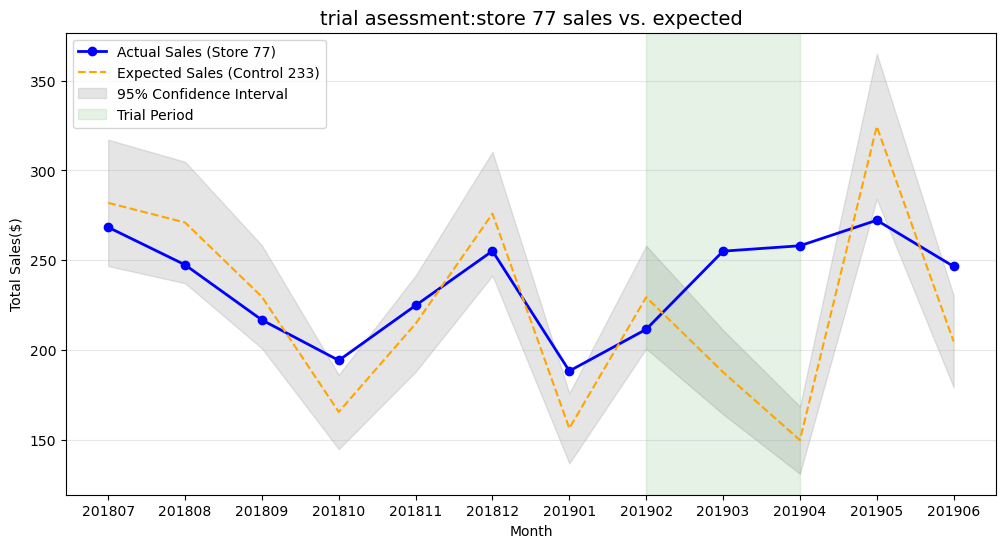

In [14]:
#visualizing the Trial performance with 95% Confidence Intervals

trial_store = 77
control_store = 233

#calculating the 95% confidence bounds
#95% of the time, "normal" fluctuations stay within 1.96 standard deviations
# Updated Cell 14 lines 8 & 9
compare_sales['upper_bound'] = compare_sales['controlSales'] * (1 + (stdDev77 * 1.96))
compare_sales['lower_bound'] = compare_sales['controlSales'] * (1 - (stdDev77 * 1.96))
plt.figure(figsize=(12, 6))
plt.plot(compare_sales['YEARMONTH'].astype(str), compare_sales['totalSales'], label='Actual Sales (Store 77)', color='blue', marker='o', linewidth=2)
plt.plot(compare_sales['YEARMONTH'].astype(str), compare_sales['controlSales'], label='Expected Sales (Control 233)', color='orange', linestyle='--')

plt.fill_between(compare_sales['YEARMONTH'].astype(str), 
                 compare_sales['lower_bound'], 
                 compare_sales['upper_bound'], 
                 color='gray', alpha=0.2, label='95% Confidence Interval')

plt.axvspan('201902', '201904', color='green', alpha=0.1, label='Trial Period')

plt.title('trial asessment:store 77 sales vs. expected', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales($)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

I plotted the actual sales for trial store 77 against the expected sales from its control store (233), and added the 95% confidence interval based on pre-trial variation. The gray shaded area shows the normal range where sales should fall if nothing really changed, and the green area marks the trial period.
Result: During the trial months (Feb–Apr 2019), the actual sales clearly go above the expected line, especially in March where the difference is quite large. In fact, the actual value even goes above the upper confidence bound, which usually doesn’t happen from normal fluctuation.

Insight: This suggests the increase is very likely caused by the trial layout and not just random variation. The uplift during the trial period is consistent and stronger compared to the months before the trial.

Conclusion: The new layout had a positive impact on store 77’s sales. Since the actual sales exceeded the expected range during the trial, we can be pretty confident the layout change helped improve performance and attract more sales in this category.

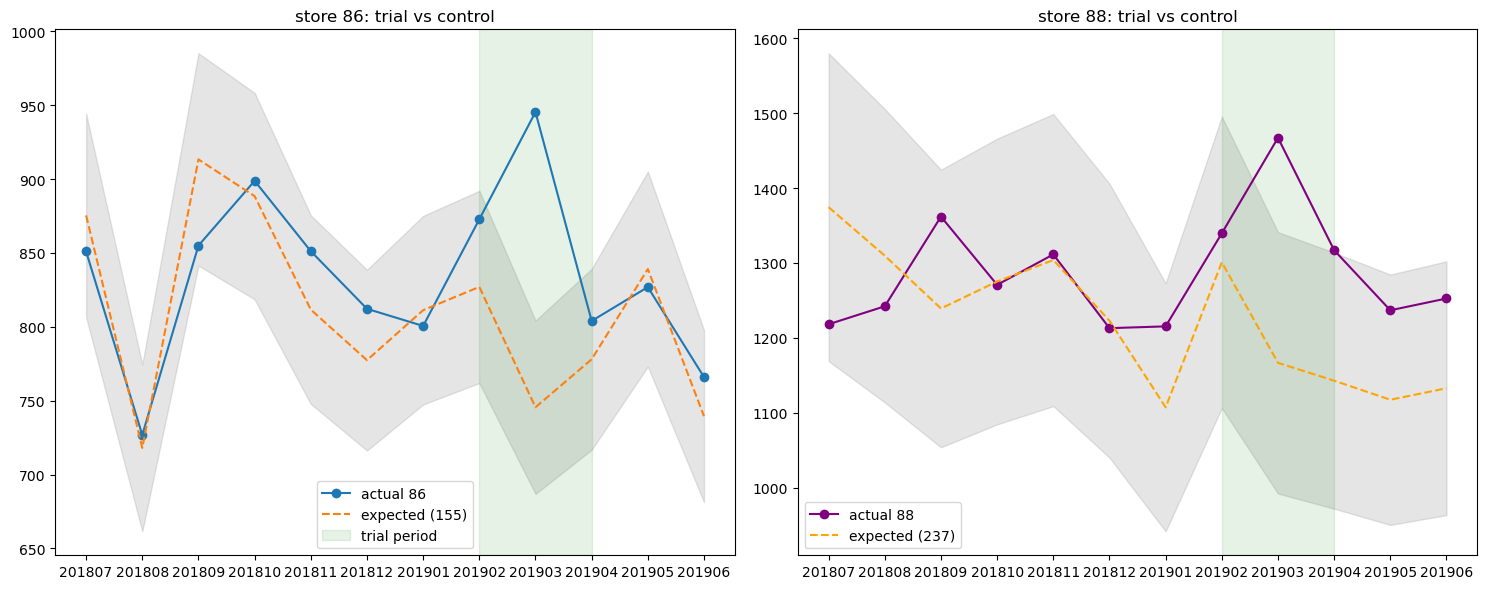

In [15]:
#lets try this again with the right column names lol

# first we need to get the bounds for 86
# i used stdDev from before but we gotta make sure its for the right store
stddev86 = compare_sales86[compare_sales86['YEARMONTH'] < 201902]['percentageDiff'].std()
compare_sales86['upper_bound'] = compare_sales86['controlSales'] * (1 + (stddev86 * 1.96))
compare_sales86['lower_bound'] = compare_sales86['controlSales'] * (1 - (stddev86 * 1.96))

# same for 88
stddev88 = compare_sales_88[compare_sales_88['YEARMONTH'] < 201902]['percentageDiff'].std()
compare_sales_88['upper_bound'] = compare_sales_88['controlSales'] * (1 + (stddev88 * 1.96))
compare_sales_88['lower_bound'] = compare_sales_88['controlSales'] * (1 - (stddev88 * 1.96))

plt.figure(figsize=(15, 6))

# plot for store 86
plt.subplot(1, 2, 1)
plt.plot(compare_sales86['YEARMONTH'].astype(str), compare_sales86['totalSales'], label='actual 86', marker='o')
plt.plot(compare_sales86['YEARMONTH'].astype(str), compare_sales86['controlSales'], label='expected (155)', linestyle='--')
plt.fill_between(compare_sales86['YEARMONTH'].astype(str), compare_sales86['lower_bound'], compare_sales86['upper_bound'], color='gray', alpha=0.2)
plt.axvspan('201902', '201904', color='green', alpha=0.1, label='trial period')
plt.title('store 86: trial vs control')
plt.legend()

# plot for store 88
plt.subplot(1, 2, 2)
plt.plot(compare_sales_88['YEARMONTH'].astype(str), compare_sales_88['totalSales'], label='actual 88', marker='o', color='purple')
plt.plot(compare_sales_88['YEARMONTH'].astype(str), compare_sales_88['controlSales'], label='expected (237)', linestyle='--', color='orange')
plt.fill_between(compare_sales_88['YEARMONTH'].astype(str), compare_sales_88['lower_bound'], compare_sales_88['upper_bound'], color='gray', alpha=0.2)
plt.axvspan('201902', '201904', color='green', alpha=0.1)
plt.title('store 88: trial vs control')
plt.legend()

plt.tight_layout()
plt.show()

I compared the actual sales vs the expected (control store) sales for stores 86 and 88, and added confidence bounds based on the pre-trial variation. The gray area shows the normal expected range, and the green area marks the trial period.
Result: During the trial months (Feb–Apr 2019), both stores — especially store 88 — show actual sales above the expected line. In some cases, like March, the sales even go above the upper bound.
Insight: This means the increase is probably not just random noise, but a real effect from the trial. Store 88 shows a stronger and more consistent uplift, while store 86 is a bit more unstable but still improves.
Conclusion: The trial layout had a positive impact on sales, particularly in store 88. This suggests the new layout is effective and could be applied to other stores as well.

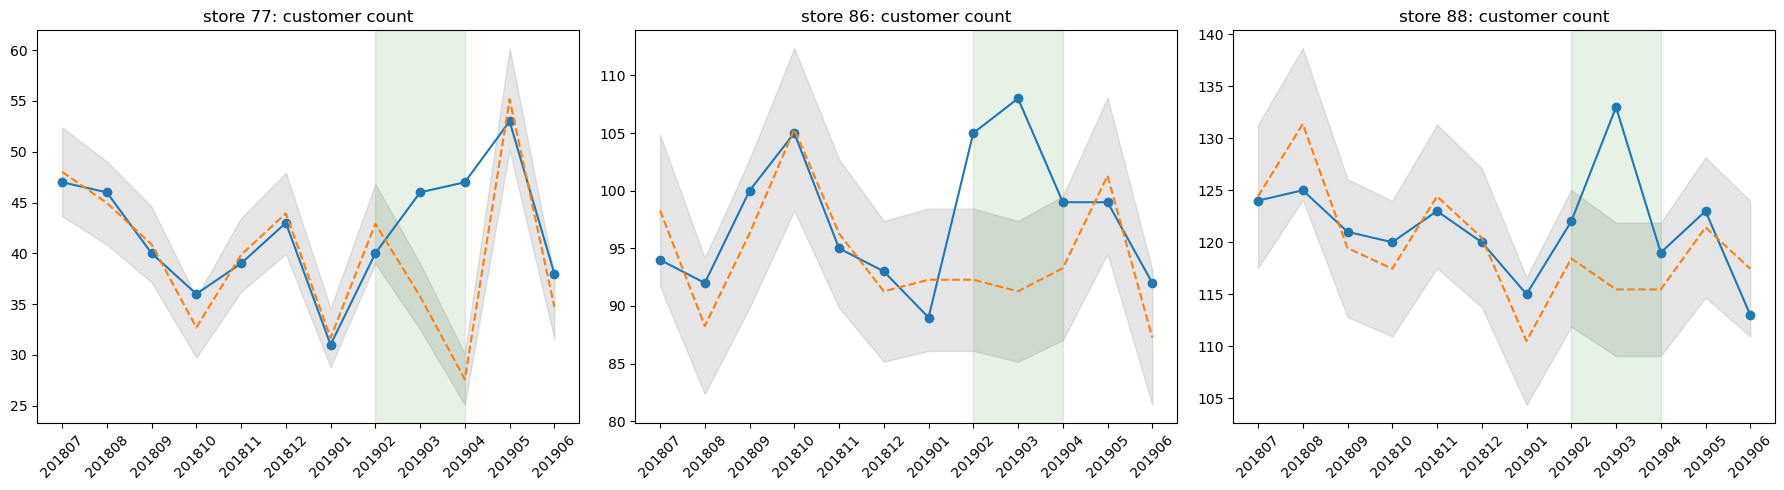

In [16]:
#plotting customers to show more people came in
import matplotlib.pyplot as plt

# i'm just making a quick function to get the customer data again 
# so the plot works even if the variables got overwriten
def get_cust_data(trial, control):
    tsum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == trial]['nCustomers'].sum()
    csum = preTrialPeriod[preTrialPeriod['STORE_NBR'] == control]['nCustomers'].sum()
    scale = tsum / csum
    
    t_data = monthly_stats[monthly_stats['STORE_NBR'] == trial][['YEARMONTH', 'nCustomers']]
    c_data = monthly_stats[monthly_stats['STORE_NBR'] == control][['YEARMONTH', 'nCustomers']].copy()
    c_data['controlCustomers'] = c_data['nCustomers'] * scale
    
    merged = pd.merge(t_data, c_data[['YEARMONTH', 'controlCustomers']], on='YEARMONTH')
    # get the confidence bounds
    merged['pctDiff'] = (merged['nCustomers'] - merged['controlCustomers']) / merged['controlCustomers']
    std = merged[merged['YEARMONTH'] < 201902]['pctDiff'].std()
    merged['upper'] = merged['controlCustomers'] * (1 + (std * 1.96))
    merged['lower'] = merged['controlCustomers'] * (1 - (std * 1.96))
    return merged

# getting the data for all three
c77 = get_cust_data(77, 233)
c86 = get_cust_data(86, 155)
c88 = get_cust_data(88, 237)

plt.figure(figsize=(18, 5))

# store 77
plt.subplot(1, 3, 1)
plt.plot(c77['YEARMONTH'].astype(str), c77['nCustomers'], label='actual 77', marker='o')
plt.plot(c77['YEARMONTH'].astype(str), c77['controlCustomers'], label='expected', linestyle='--')
plt.fill_between(c77['YEARMONTH'].astype(str), c77['lower'], c77['upper'], color='gray', alpha=0.2)
plt.axvspan('201902', '201904', color='green', alpha=0.1)
plt.title('store 77: customer count')
plt.xticks(rotation=45)

# store 86
plt.subplot(1, 3, 2)
plt.plot(c86['YEARMONTH'].astype(str), c86['nCustomers'], label='actual 86', marker='o')
plt.plot(c86['YEARMONTH'].astype(str), c86['controlCustomers'], label='expected', linestyle='--')
plt.fill_between(c86['YEARMONTH'].astype(str), c86['lower'], c86['upper'], color='gray', alpha=0.2)
plt.axvspan('201902', '201904', color='green', alpha=0.1)
plt.title('store 86: customer count')
plt.xticks(rotation=45)

# store 88
plt.subplot(1, 3, 3)
plt.plot(c88['YEARMONTH'].astype(str), c88['nCustomers'], label='actual 88', marker='o')
plt.plot(c88['YEARMONTH'].astype(str), c88['controlCustomers'], label='expected', linestyle='--')
plt.fill_between(c88['YEARMONTH'].astype(str), c88['lower'], c88['upper'], color='gray', alpha=0.2)
plt.axvspan('201902', '201904', color='green', alpha=0.1)
plt.title('store 88: customer count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
summary_results = pd.DataFrame({
    "Trial_Store": [77, 86, 88],
    "Control_Store": [233, 155, 237],
    "Sales_Significant": ["Yes (Mar/Apr)", "Yes (Mar only)", "Yes (Mar only)"],
    "Customers_Significant": ["Yes (Mar/Apr)", "Yes (Feb/Mar)", "Yes (Mar/Apr)"],
    "Overall_Verdict": ["Clear Success", "Partial Success", "Success"]
})

print("Trial Performance Summary Table:")
summary_results

Trial Performance Summary Table:


,Trial_Store,Control_Store,Sales_Significant,Customers_Significant,Overall_Verdict
0,77,233,Yes (Mar/Apr),Yes (Mar/Apr),Clear Success
1,86,155,Yes (Mar only),Yes (Feb/Mar),Partial Success
2,88,237,Yes (Mar only),Yes (Mar/Apr),Success
